<a href="https://colab.research.google.com/github/Andreina-A/Data620/blob/main/Assignmentweek8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Andreina Arias
Week 8 assignment- High Frequency Words



1. Choose a corpus of interest.
2. How many total unique words are in the corpus? (Please feel free to define unique words in any interesting, defensible way).
3. Taking the most common words, how many unique words represent half of the total words in the corpus?
4. Identify the 200 highest frequency words in this corpus.
5. Create a graph that shows the relative frequency of these 200 words.
6. Does the observed relative frequency of these words follow Zipf’s law? Explain.
7. In what ways do you think the frequency of the words in this corpus differ from “all words in all corpora.”


I'll be using a corpus of Alice in Wonderland from the Gutenberg library which can be downloaded from the NLTK package.

In [6]:
#Load packages
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import string
from collections import Counter
import nltk
nltk.download('gutenberg')
from nltk.corpus import gutenberg
print(gutenberg.fileids())#list of text in gutenberg

['austen-emma.txt', 'austen-persuasion.txt', 'austen-sense.txt', 'bible-kjv.txt', 'blake-poems.txt', 'bryant-stories.txt', 'burgess-busterbrown.txt', 'carroll-alice.txt', 'chesterton-ball.txt', 'chesterton-brown.txt', 'chesterton-thursday.txt', 'edgeworth-parents.txt', 'melville-moby_dick.txt', 'milton-paradise.txt', 'shakespeare-caesar.txt', 'shakespeare-hamlet.txt', 'shakespeare-macbeth.txt', 'whitman-leaves.txt']


[nltk_data] Downloading package gutenberg to /root/nltk_data...
[nltk_data]   Package gutenberg is already up-to-date!


In [9]:
Alice=gutenberg.words('carroll-alice.txt') #words from Alice in wonderland corpus in the alice variable
print(len(Alice)) #Find how many words are in the corpus
print(list(Alice)[:10]) #some characters are being considered at words

34110
['[', 'Alice', "'", 's', 'Adventures', 'in', 'Wonderland', 'by', 'Lewis', 'Carroll']


In [10]:
#made all the text lower case and made sure sympbols were counted as a word
clean_Alice=[
    word.lower().strip(string.punctuation)
    for word in Alice
    if word.strip(string.punctuation)
]

In [11]:
print(len(clean_Alice)) #Find how many words are in the corpus without punctuation being counted as a word
print(list(clean_Alice)[:10])

27336
['alice', 's', 'adventures', 'in', 'wonderland', 'by', 'lewis', 'carroll', '1865', 'chapter']


In [12]:
#Count of unique words in Alice in wonderland
Alice_list=clean_Alice
unique_Alice=set(Alice_list) #used set to remove duplicate word
print(len(unique_Alice))

2570


In [13]:
#top ten most used words in the text
word_counts=Counter(clean_Alice)
print(word_counts.most_common(10))

[('the', 1642), ('and', 872), ('to', 729), ('a', 632), ('it', 595), ('she', 553), ('i', 545), ('of', 514), ('said', 462), ('you', 411)]


In [14]:
#the words contributing to the 50% of the text
sorted_counts= word_counts.most_common()
total_words=sum(word_counts.values())
running_total=0
selected_words=[]
for word, count in sorted_counts:
    running_total+=count
    selected_words.append((word, count))
    if running_total>= total_words /2:
      break
print(len(selected_words))
print(selected_words)

54
[('the', 1642), ('and', 872), ('to', 729), ('a', 632), ('it', 595), ('she', 553), ('i', 545), ('of', 514), ('said', 462), ('you', 411), ('alice', 398), ('in', 369), ('was', 357), ('that', 315), ('as', 263), ('her', 248), ('t', 218), ('at', 212), ('s', 201), ('on', 193), ('all', 182), ('with', 180), ('had', 178), ('but', 170), ('for', 153), ('they', 152), ('so', 151), ('be', 148), ('not', 145), ('very', 144), ('what', 141), ('this', 134), ('little', 128), ('he', 125), ('out', 117), ('is', 108), ('one', 104), ('down', 102), ('up', 100), ('there', 99), ('if', 96), ('his', 96), ('then', 94), ('about', 94), ('no', 90), ('them', 88), ('know', 88), ('like', 85), ('were', 85), ('would', 83), ('went', 83), ('again', 83), ('herself', 83), ('do', 81)]


In [15]:
#highest 200 words used in the text
top_200= word_counts.most_common(200)
print(top_200)

[('the', 1642), ('and', 872), ('to', 729), ('a', 632), ('it', 595), ('she', 553), ('i', 545), ('of', 514), ('said', 462), ('you', 411), ('alice', 398), ('in', 369), ('was', 357), ('that', 315), ('as', 263), ('her', 248), ('t', 218), ('at', 212), ('s', 201), ('on', 193), ('all', 182), ('with', 180), ('had', 178), ('but', 170), ('for', 153), ('they', 152), ('so', 151), ('be', 148), ('not', 145), ('very', 144), ('what', 141), ('this', 134), ('little', 128), ('he', 125), ('out', 117), ('is', 108), ('one', 104), ('down', 102), ('up', 100), ('there', 99), ('if', 96), ('his', 96), ('then', 94), ('about', 94), ('no', 90), ('them', 88), ('know', 88), ('like', 85), ('were', 85), ('would', 83), ('went', 83), ('again', 83), ('herself', 83), ('do', 81), ('have', 80), ('when', 79), ('or', 77), ('could', 77), ('queen', 75), ('thought', 74), ('off', 73), ('time', 71), ('how', 68), ('me', 68), ('into', 67), ('see', 67), ('well', 63), ('did', 63), ('m', 63), ('who', 63), ('can', 63), ('king', 63), ('you

In [16]:
#obtained frequency
words=[word for word, count in top_200]
relative_frequency=[count / total_words for word, count in top_200]

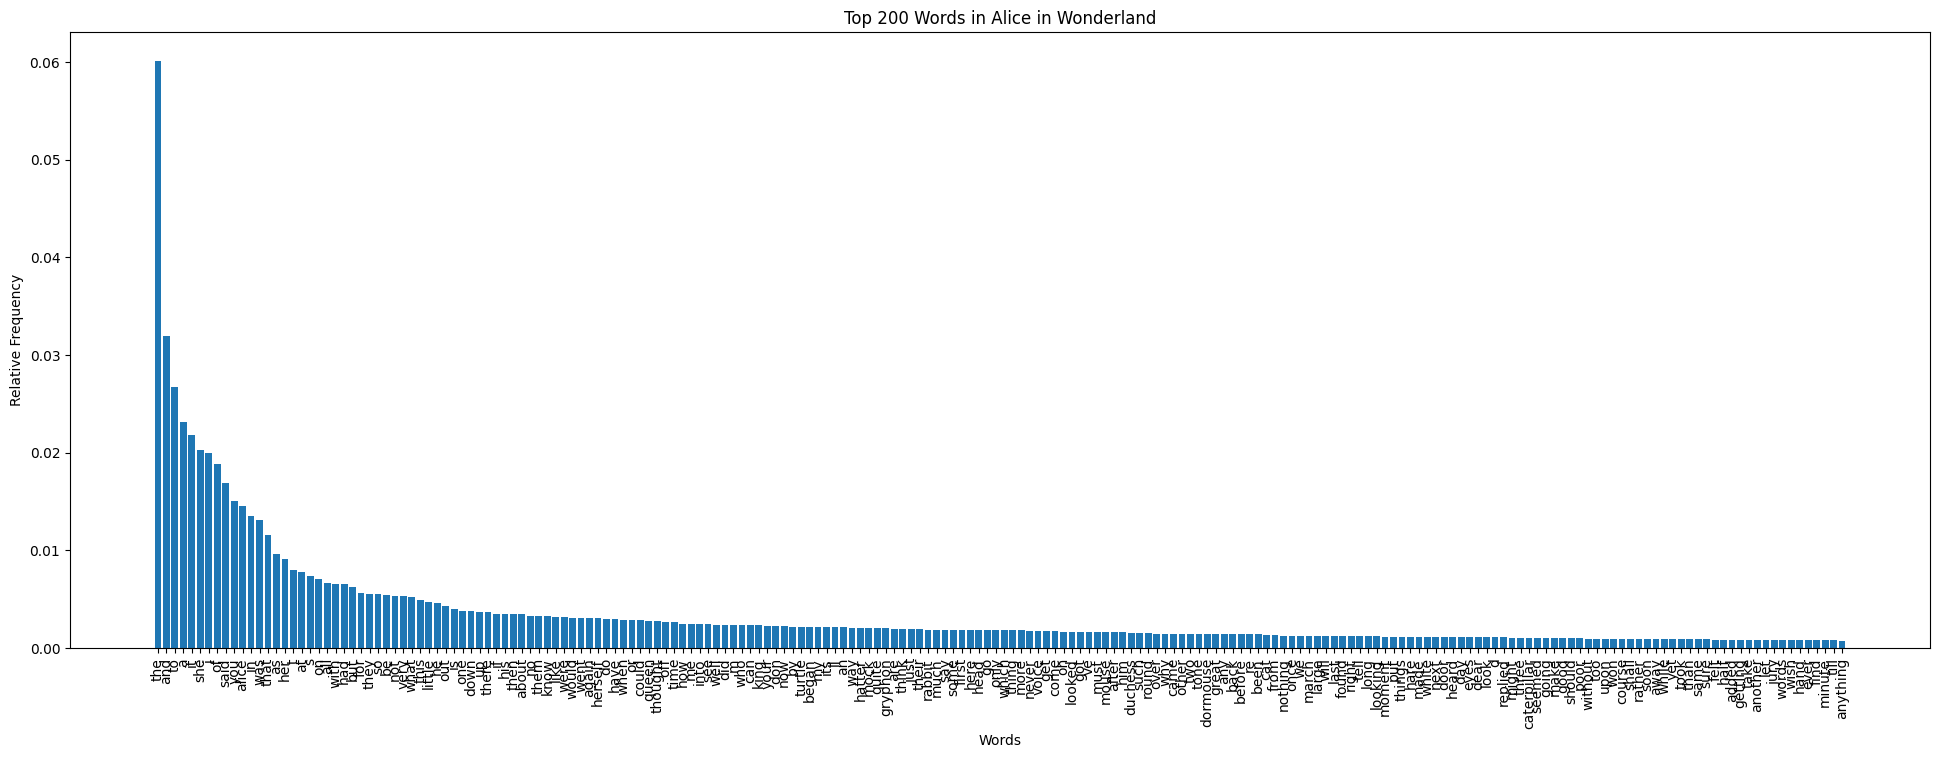

In [17]:
#bar graph of the top 200 words
plt.figure(figsize=(24, 8))
plt.bar(words, relative_frequency)
plt.xlabel('Words')
plt.ylabel('Relative Frequency')
plt.title('Top 200 Words in Alice in Wonderland')
plt.xticks(rotation=90)
plt.show()

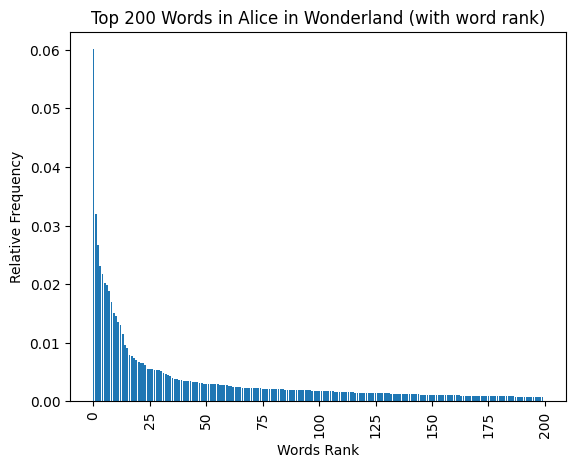

In [18]:
#bar graph of the top 200 words
plt.bar(range(len(words)), relative_frequency)
plt.xlabel('Words Rank')
plt.ylabel('Relative Frequency')
plt.title('Top 200 Words in Alice in Wonderland (with word rank)')
plt.xticks(rotation=90)
plt.show()

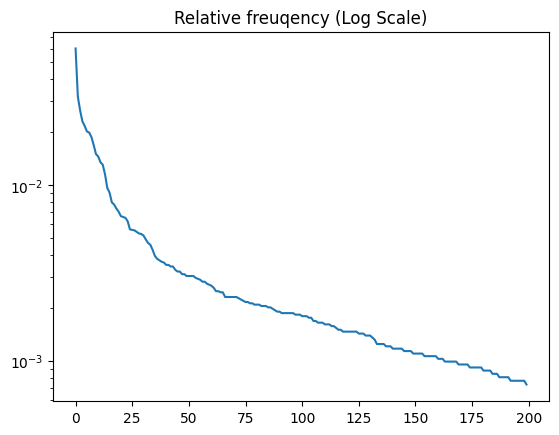

In [19]:
plt.plot(relative_frequency)
plt.yscale("log")
plt.title("Relative freuqency (Log Scale)")
plt.show()

Zipf's law says the frequency of an item is inversely proportional to its rank, if words are ranked by frequency you'll find the the most common word like "the" (https://masoudbahrami.medium.com/zipfs-law-a-universal-pattern-in-our-data-driven-world-4d6c564d848c). Looking at the top 200 words bar graph with the word ranks against their relative frequency it is seen that the Alice in wonderland text follow the Zipf's law as the rank are inversely proportional. It is also seen on the log scale graph of the relative frequency, the graph has a concaved upwards decreasing curve. These graphs showed that as the most words dominiate and frequencies decreases with rank.

In [20]:
#load top 50k English words from github for comparsion
url = "https://raw.githubusercontent.com/hermitdave/FrequencyWords/master/content/2018/en/en_50k.txt"

import requests
r = requests.get(url)
with open("en_50k.txt", "w", encoding="utf-8") as f:
    f.write(r.text)
print("Downloaded top 50k English words.")

Downloaded top 50k English words.


495518434


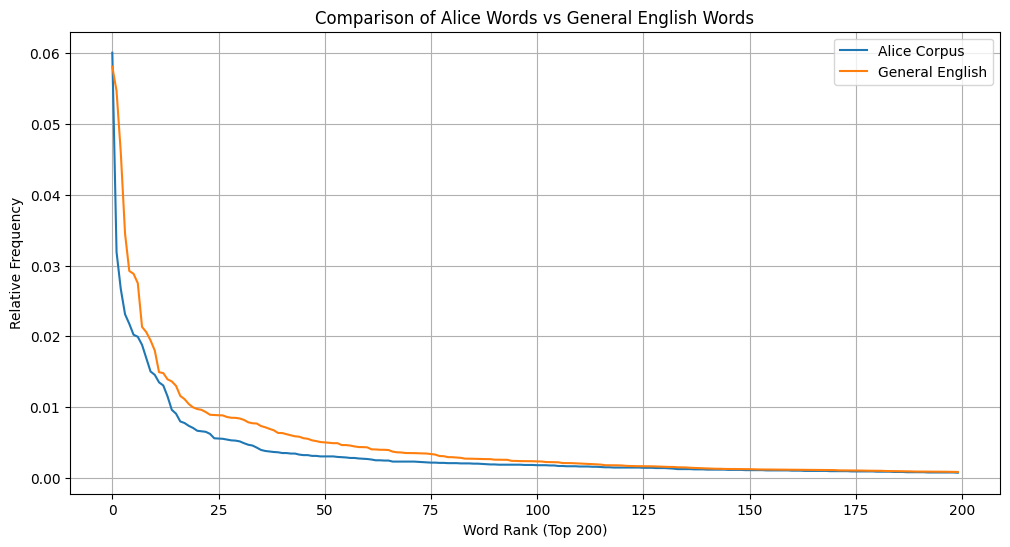

In [21]:
# load top 200 words from github raw data
general_words = []
general_freqs = []

with open("en_50k.txt", encoding="utf-8") as f:
    for i, line in enumerate(f):
        if i >= 200:  # top 200
            break
        word, freq = line.strip().split()
        general_words.append(word)
        general_freqs.append(int(freq))

# obtained github relative frequency
total_general = sum(general_freqs)
general_rel_freqs = [f / total_general for f in general_freqs]

print(total_general)

plt.figure(figsize=(12,6))
plt.plot(relative_frequency, label="Alice Corpus")
plt.plot(general_rel_freqs, label="General English")
plt.xlabel("Word Rank (Top 200)")
plt.ylabel("Relative Frequency")
plt.title("Comparison of Alice Words vs General English Words")
plt.legend()
plt.grid(True)
plt.show()

This corpus doesn't seem to have much a difference from "all words in all corpora". I used a list of top 50k english words from Github and took the top 200 words to compare it to the top 200 words in Alice in wonderland. It was in the graph there is a slight different, but this could be because the words in Alice in wonderland had less counts there were less words in the text compared Github download that had a total of 495,518,434 words.